In [ ]:
# CELL 1 — Download the processed scRNA-seq data directly from GEO's FTP
# (skips manual browser download; runs straight in Colab)
# =============================================================================
!wget -O GSE176078_scRNA.tar.gz \
  "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176078/suppl/GSE176078_Wu_etal_2021_BRCA_scRNASeq.tar.gz"

!tar -xzf GSE176078_scRNA.tar.gz
!find . -maxdepth 3 -iname "*.tsv*" -o -iname "*.mtx*" -o -iname "*.csv*" | head -20

--2026-09-23 01:59:18--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE176nnn/GSE176078/suppl/GSE176078_Wu_etal_2021_BRCA_scRNASeq.tar.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.10, 130.14.250.11, 2607:f220:41e:250::10, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 558829202 (533M) [application/x-gzip]
Saving to: ‘GSE176078_scRNA.tar.gz’

GSE176078_scRNA.tar 100%[===================>] 532.94M  89.8MB/s    in 7.0s    

2026-09-23 01:59:26 (76.2 MB/s) - ‘GSE176078_scRNA.tar.gz’ saved [558829202/558829202]

./Wu_etal_2021_BRCA_scRNASeq/count_matrix_genes.tsv
./Wu_etal_2021_BRCA_scRNASeq/count_matrix_sparse.mtx
./Wu_etal_2021_BRCA_scRNASeq/count_matrix_barcodes.tsv
./Wu_etal_2021_BRCA_scRNASeq/metadata.csv
./sample_data/mnist_train_small.csv
./sample_data/california_housing_test.csv
./sample_data/mnist_test.csv
./sample_data/california_housing_train.csv


In [ ]:
# CELL 2 — Imports
# =============================================================================
!pip install scanpy anndata --quiet

import scanpy as sc
import anndata as ad
import pandas as pd
import scipy.io as sio
import scipy.sparse as sp
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.2/190.2 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas=

In [ ]:
# CELL 3 — Load the combined matrix + metadata
# NOTE: adjust the folder/file names below once Cell 1's `find` output shows
# the actual extracted paths — GEO tarballs sometimes nest an extra folder.
# =============================================================================
DATA_DIR = "Wu_etal_2021_BRCA_scRNASeq"  # <-- confirm this matches the extracted folder name

barcodes = pd.read_csv(f"{DATA_DIR}/count_matrix_barcodes.tsv", header=None, sep="\t")[0].values
genes    = pd.read_csv(f"{DATA_DIR}/count_matrix_genes.tsv", header=None, sep="\t")[0].values
matrix   = sio.mmread(f"{DATA_DIR}/count_matrix_sparse.mtx").tocsr()

# mtx is typically genes x cells — transpose if needed so rows=cells, cols=genes
if matrix.shape[0] == len(genes):
    matrix = matrix.T

metadata = pd.read_csv(f"{DATA_DIR}/metadata.csv", index_col=0)

print("Matrix shape (cells x genes):", matrix.shape)
print("Metadata shape:", metadata.shape)
print("\nMetadata columns:", metadata.columns.tolist())
print("\nSubtype breakdown:")
print(metadata.filter(like="subtype", axis=1).apply(pd.Series.value_counts) if
      any("subtype" in c.lower() for c in metadata.columns) else "look for the subtype-like column manually below")
print(metadata.head())


Matrix shape (cells x genes): (100064, 29733)
Metadata shape: (100064, 8)

Metadata columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major']

Subtype breakdown:
         subtype
subtype         
TNBC       42512
ER+        38241
HER2+      19311
                         orig.ident  nCount_RNA  nFeature_RNA  percent.mito  \
CID3586_AAGACCTCAGCATGAG    CID3586        4581          1689      1.506221   
CID3586_AAGGTTCGTAGTACCT    CID3586        1726           779      5.793743   
CID3586_ACCAGTAGTTGTGGCC    CID3586        1229           514      1.383238   
CID3586_ACCCACTAGATGTCGG    CID3586        1352           609      1.923077   
CID3586_ACTGATGGTCAACTGT    CID3586        1711           807     13.325541   

                         subtype    celltype_subset     celltype_minor  \
CID3586_AAGACCTCAGCATGAG   HER2+  Endothelial ACKR1  Endothelial ACKR1   
CID3586_AAGGTTCGTAGTACCT   HER2+  Endothelial ACKR1 

In [ ]:
# CELL 4 — Build full AnnData object
# =============================================================================
adata = ad.AnnData(X=matrix, obs=pd.DataFrame(index=barcodes), var=pd.DataFrame(index=genes))
adata.obs = adata.obs.join(metadata, how="left")

print(adata)
print("\nTGFBR1 present:", "TGFBR1" in adata.var_names)


AnnData object with n_obs × n_vars = 100064 × 29733
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major'
    layers: None (.X)

TGFBR1 present: True


In [ ]:
SUBTYPE_COL = "subtype"   # confirmed correct
TNBC_LABEL = "TNBC"       # confirmed correct

adata_tnbc = adata[adata.obs[SUBTYPE_COL] == TNBC_LABEL].copy()

print(f"\nTNBC cells: {adata_tnbc.n_obs}")
print(f"TNBC patient samples: {adata_tnbc.obs['orig.ident'].nunique()}")
print(adata_tnbc.obs['orig.ident'].drop_duplicates().tolist())

adata_tnbc.write("GSE176078_TNBC_subset.h5ad")
print("\nSaved: GSE176078_TNBC_subset.h5ad")


TNBC cells: 42512
TNBC patient samples: 10
['CID44041', 'CID4465', 'CID4495', 'CID44971', 'CID44991', 'CID4513', 'CID4515', 'CID4523', 'CID3946', 'CID3963']

Saved: GSE176078_TNBC_subset.h5ad


In [ ]:
# CELL 6 — TGFBR1 expression across TNBC patients and cell types
# =============================================================================
# Normalize + log-transform first — raw counts aren't comparable across cells
# with different sequencing depth (skip this if adata.X is already normalized)
sc.pp.normalize_total(adata_tnbc, target_sum=1e4)
sc.pp.log1p(adata_tnbc)

tgfbr1_expr = adata_tnbc[:, "TGFBR1"].X
tgfbr1_expr = tgfbr1_expr.toarray().flatten() if sp.issparse(tgfbr1_expr) else np.asarray(tgfbr1_expr).flatten()
adata_tnbc.obs["TGFBR1_expr"] = tgfbr1_expr

# Per-patient breakdown
print("--- Per patient ---")
print(adata_tnbc.obs.groupby("orig.ident")["TGFBR1_expr"].describe())

# Per cell type — this is the one that actually tells you something biological
print("\n--- Per cell type (major) ---")
grouped = adata_tnbc.obs.groupby("celltype_major")["TGFBR1_expr"]
result = pd.DataFrame({
    "mean_expr": grouped.mean(),
    "pct_expressing": grouped.apply(lambda x: (x > 0).mean() * 100),
    "n_cells": grouped.count()
}).sort_values("mean_expr", ascending=False)
print(result)

--- Per patient ---
             count      mean       std  min  25%  50%  75%       max
orig.ident                                                          
CID3946      774.0  0.040001  0.290891  0.0  0.0  0.0  0.0  3.145110
CID3963     3527.0  0.074598  0.317106  0.0  0.0  0.0  0.0  2.954825
CID4465     1564.0  0.040936  0.310885  0.0  0.0  0.0  0.0  3.243785
CID4495     7985.0  0.040586  0.211960  0.0  0.0  0.0  0.0  2.449453
CID4513     5619.0  0.140290  0.360696  0.0  0.0  0.0  0.0  2.433176
CID4515     4149.0  0.066075  0.254337  0.0  0.0  0.0  0.0  2.627940
CID4523     1754.0  0.073821  0.298618  0.0  0.0  0.0  0.0  3.220413
CID44041    2131.0  0.053257  0.263437  0.0  0.0  0.0  0.0  2.371941
CID44971    7986.0  0.041338  0.216456  0.0  0.0  0.0  0.0  2.527386
CID44991    7023.0  0.127185  0.342932  0.0  0.0  0.0  0.0  3.111701

--- Per cell type (major) ---
                   mean_expr  pct_expressing  n_cells
celltype_major                                       
Myeloid      

In [ ]:
# CELL 7 — TGFBR1-high vs TGFBR1-low cancer epithelial cells: EMT marker comparison
# =============================================================================
cancer_epi = adata_tnbc[adata_tnbc.obs["celltype_major"] == "Cancer Epithelial"].copy()

tgfbr1_pos = cancer_epi.obs["TGFBR1_expr"] > 0
cancer_epi.obs["TGFBR1_group"] = np.where(tgfbr1_pos, "TGFBR1+", "TGFBR1-")

print(cancer_epi.obs["TGFBR1_group"].value_counts())

emt_markers = ["CDH1", "CDH2", "VIM", "TWIST1", "ZEB1", "SNAI1", "TGFB1", "SMAD3", "SMAD4"]
present_markers = [g for g in emt_markers if g in cancer_epi.var_names]
missing_markers = [g for g in emt_markers if g not in cancer_epi.var_names]
print(f"\nPresent: {present_markers}")
print(f"Missing: {missing_markers}")

marker_expr = cancer_epi[:, present_markers].X
marker_expr = marker_expr.toarray() if sp.issparse(marker_expr) else np.asarray(marker_expr)
marker_df = pd.DataFrame(marker_expr, columns=present_markers, index=cancer_epi.obs_names)
marker_df["TGFBR1_group"] = cancer_epi.obs["TGFBR1_group"].values

from scipy import stats
print("\n--- EMT marker comparison: TGFBR1+ vs TGFBR1- cancer epithelial cells ---")
for gene in present_markers:
    pos_vals = marker_df.loc[marker_df["TGFBR1_group"] == "TGFBR1+", gene]
    neg_vals = marker_df.loc[marker_df["TGFBR1_group"] == "TGFBR1-", gene]
    stat, pval = stats.mannwhitneyu(pos_vals, neg_vals, alternative="two-sided")
    direction = "UP" if pos_vals.mean() > neg_vals.mean() else "DOWN"
    print(f"{gene:10s}  TGFBR1+ mean={pos_vals.mean():.3f}  TGFBR1- mean={neg_vals.mean():.3f}  ({direction} in TGFBR1+)  p={pval:.2e}")

mean_by_group = marker_df.groupby("TGFBR1_group")[present_markers].mean()
print("\n--- Mean expression by group ---")
print(mean_by_group)

TGFBR1_group
TGFBR1-    9263
TGFBR1+    1573
Name: count, dtype: int64

Present: ['CDH1', 'CDH2', 'VIM', 'TWIST1', 'ZEB1', 'SNAI1', 'TGFB1', 'SMAD3', 'SMAD4']
Missing: []

--- EMT marker comparison: TGFBR1+ vs TGFBR1- cancer epithelial cells ---
CDH1        TGFBR1+ mean=0.314  TGFBR1- mean=0.183  (UP in TGFBR1+)  p=1.78e-62
CDH2        TGFBR1+ mean=0.010  TGFBR1- mean=0.010  (DOWN in TGFBR1+)  p=2.03e-03
VIM         TGFBR1+ mean=0.988  TGFBR1- mean=1.626  (DOWN in TGFBR1+)  p=1.51e-42
TWIST1      TGFBR1+ mean=0.009  TGFBR1- mean=0.010  (DOWN in TGFBR1+)  p=4.43e-01
ZEB1        TGFBR1+ mean=0.043  TGFBR1- mean=0.039  (UP in TGFBR1+)  p=2.62e-03
SNAI1       TGFBR1+ mean=0.034  TGFBR1- mean=0.032  (UP in TGFBR1+)  p=1.11e-04
TGFB1       TGFBR1+ mean=0.095  TGFBR1- mean=0.095  (DOWN in TGFBR1+)  p=3.22e-02
SMAD3       TGFBR1+ mean=0.075  TGFBR1- mean=0.055  (UP in TGFBR1+)  p=8.26e-16
SMAD4       TGFBR1+ mean=0.083  TGFBR1- mean=0.066  (UP in TGFBR1+)  p=3.33e-13

--- Mean expression by gr

In [ ]:
# CELL 7b — Sharper cut: top vs bottom quartile of TGFBR1 expression
# (only among cells that express it at all, to avoid quartiles being
# dominated by the zero-mass — quartiles of a mostly-zero distribution
# would just recreate the same any-vs-none split)
# =============================================================================
expressing = cancer_epi[cancer_epi.obs["TGFBR1_expr"] > 0].copy()
print(f"Cells expressing TGFBR1 at all: {expressing.n_obs} (out of {cancer_epi.n_obs} total)")

q25 = expressing.obs["TGFBR1_expr"].quantile(0.25)
q75 = expressing.obs["TGFBR1_expr"].quantile(0.75)
print(f"25th percentile (among expressers): {q25:.4f}")
print(f"75th percentile (among expressers): {q75:.4f}")

top_mask = expressing.obs["TGFBR1_expr"] >= q75
bottom_mask = expressing.obs["TGFBR1_expr"] <= q25

quartile_subset = expressing[top_mask | bottom_mask].copy()
quartile_subset.obs["TGFBR1_quartile"] = np.where(
    quartile_subset.obs["TGFBR1_expr"] >= q75, "Top25%", "Bottom25%"
)

print(quartile_subset.obs["TGFBR1_quartile"].value_counts())

# Extract EMT marker expression for this quartile subset
marker_expr_q = quartile_subset[:, present_markers].X
marker_expr_q = marker_expr_q.toarray() if sp.issparse(marker_expr_q) else np.asarray(marker_expr_q)
marker_df_q = pd.DataFrame(marker_expr_q, columns=present_markers, index=quartile_subset.obs_names)
marker_df_q["TGFBR1_quartile"] = quartile_subset.obs["TGFBR1_quartile"].values

print("\n--- EMT marker comparison: Top25% vs Bottom25% TGFBR1 expressers ---")
for gene in present_markers:
    top_vals = marker_df_q.loc[marker_df_q["TGFBR1_quartile"] == "Top25%", gene]
    bot_vals = marker_df_q.loc[marker_df_q["TGFBR1_quartile"] == "Bottom25%", gene]
    stat, pval = stats.mannwhitneyu(top_vals, bot_vals, alternative="two-sided")
    direction = "UP" if top_vals.mean() > bot_vals.mean() else "DOWN"
    fold = (top_vals.mean() + 0.01) / (bot_vals.mean() + 0.01)  # small pseudocount, avoid div/0
    print(f"{gene:10s}  Top25% mean={top_vals.mean():.3f}  Bottom25% mean={bot_vals.mean():.3f}  "
          f"({direction} in Top25%, ~{fold:.2f}x)  p={pval:.2e}")

mean_by_quartile = marker_df_q.groupby("TGFBR1_quartile")[present_markers].mean()
print("\n--- Mean expression by quartile ---")
print(mean_by_quartile)

Cells expressing TGFBR1 at all: 1573 (out of 10836 total)
25th percentile (among expressers): 0.3351
75th percentile (among expressers): 0.8574
TGFBR1_quartile
Top25%       394
Bottom25%    394
Name: count, dtype: int64

--- EMT marker comparison: Top25% vs Bottom25% TGFBR1 expressers ---
CDH1        Top25% mean=0.361  Bottom25% mean=0.207  (UP in Top25%, ~1.71x)  p=9.30e-01
CDH2        Top25% mean=0.000  Bottom25% mean=0.019  (DOWN in Top25%, ~0.34x)  p=1.27e-07
VIM         Top25% mean=0.282  Bottom25% mean=2.384  (DOWN in Top25%, ~0.12x)  p=4.62e-68
TWIST1      Top25% mean=0.002  Bottom25% mean=0.025  (DOWN in Top25%, ~0.36x)  p=4.30e-09
ZEB1        Top25% mean=0.016  Bottom25% mean=0.114  (DOWN in Top25%, ~0.21x)  p=2.18e-17
SNAI1       Top25% mean=0.028  Bottom25% mean=0.037  (DOWN in Top25%, ~0.82x)  p=1.52e-09
TGFB1       Top25% mean=0.027  Bottom25% mean=0.206  (DOWN in Top25%, ~0.17x)  p=1.16e-18
SMAD3       Top25% mean=0.054  Bottom25% mean=0.126  (DOWN in Top25%, ~0.47x)  p=1

/tmp/ipykernel_3060/813458275.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=marker_df, x="TGFBR1_group", y=gene, ax=ax,
/tmp/ipykernel_3060/813458275.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=marker_df, x="TGFBR1_group", y=gene, ax=ax,
/tmp/ipykernel_3060/813458275.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=marker_df, x="TGFBR1_group", y=gene, ax=ax,
/tmp/ipykernel_3060/813458275.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. 

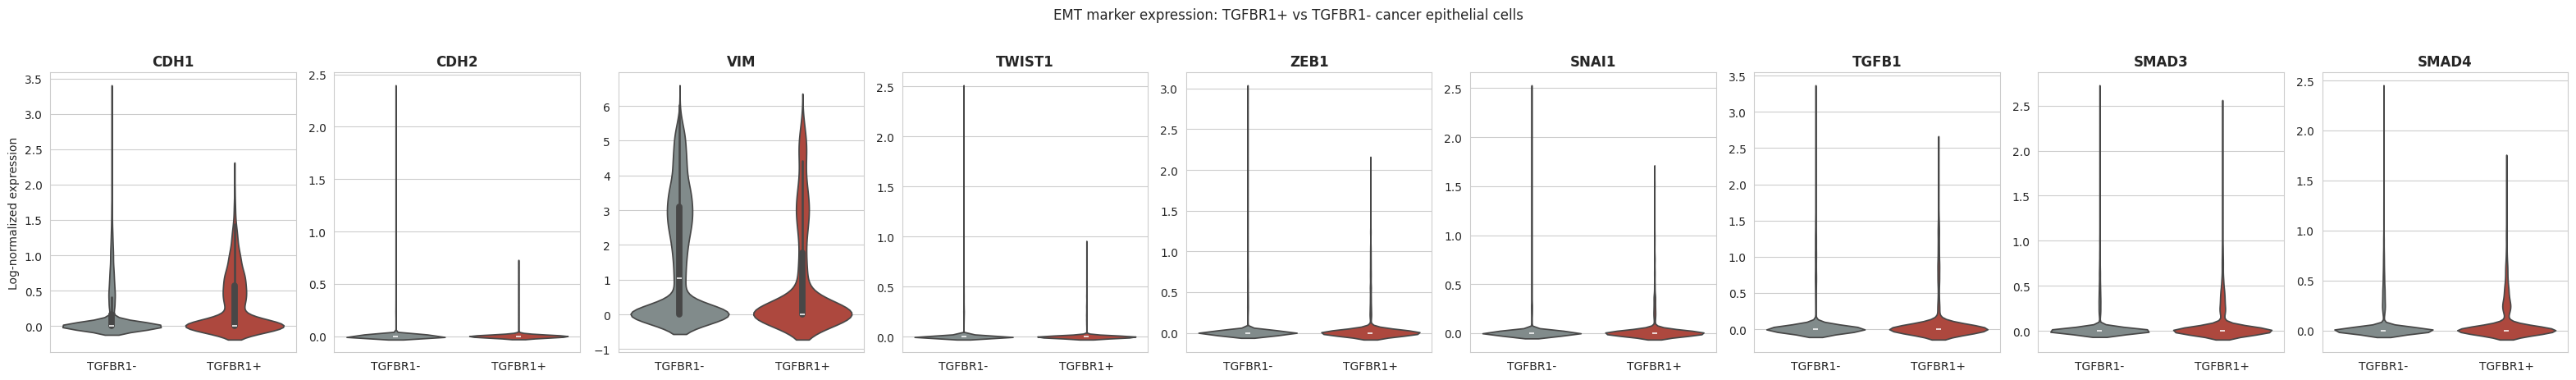

In [ ]:
# CELL 8 — Visualize TGFBR1+ vs TGFBR1- EMT marker differences
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---- Panel A: Violin plots, one per EMT marker, split by TGFBR1 group ----
n_markers = len(present_markers)
fig, axes = plt.subplots(1, n_markers, figsize=(3.5 * n_markers, 4.5))
if n_markers == 1:
    axes = [axes]

for ax, gene in zip(axes, present_markers):
    sns.violinplot(data=marker_df, x="TGFBR1_group", y=gene, ax=ax,
                    palette={"TGFBR1+": "#c0392b", "TGFBR1-": "#7f8c8d"},
                    order=["TGFBR1-", "TGFBR1+"])
    ax.set_title(gene, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Log-normalized expression" if ax is axes[0] else "")

plt.suptitle("EMT marker expression: TGFBR1+ vs TGFBR1- cancer epithelial cells", y=1.02)
plt.tight_layout()
plt.savefig("emt_markers_violin_tgfbr1.png", dpi=300, bbox_inches="tight")
plt.show()

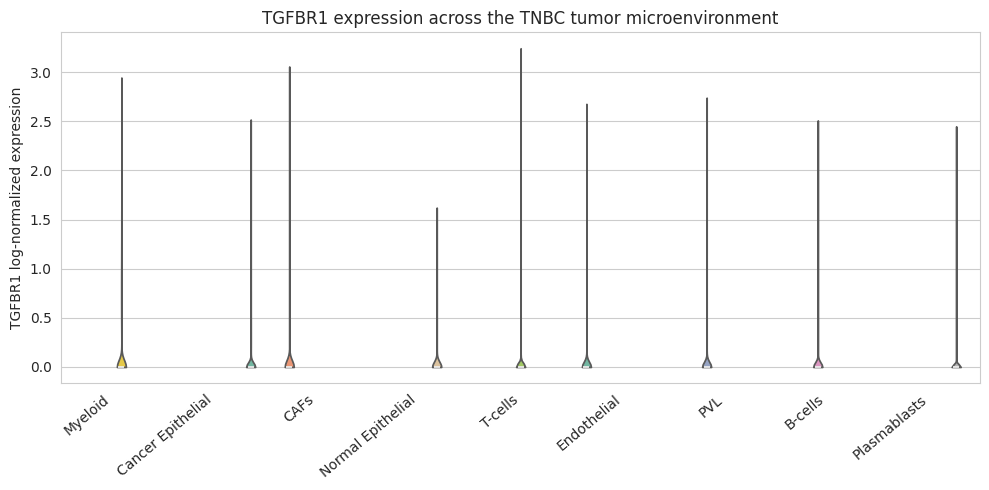

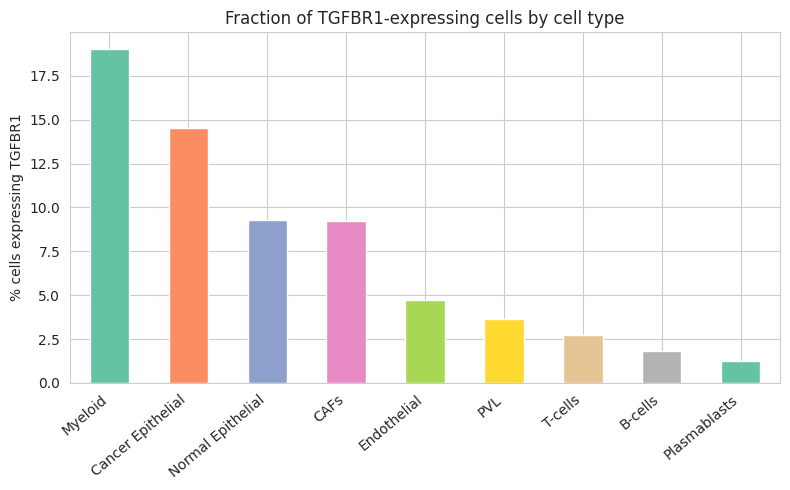

/tmp/ipykernel_3060/845766737.py:42: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(adata_tnbc, n_comps=30, use_highly_variable=True)


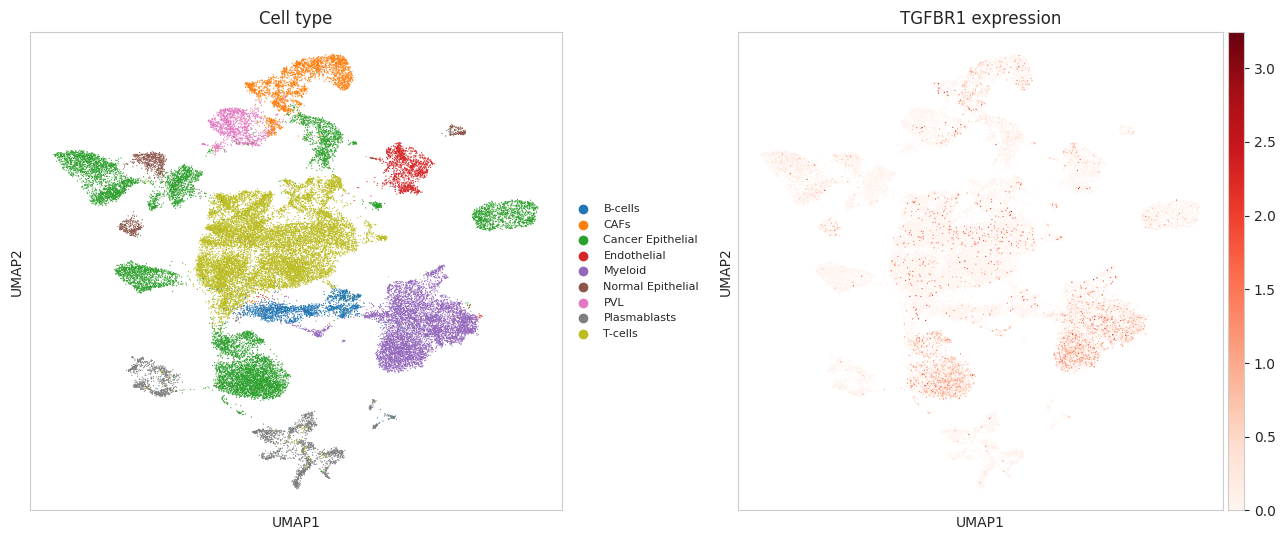

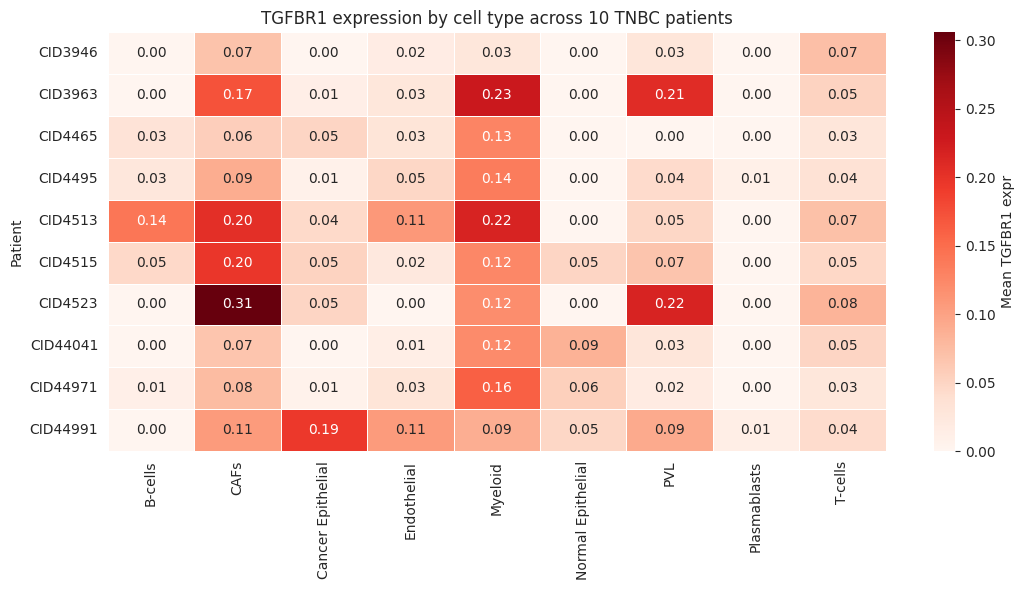

In [ ]:
# CELL 9 — TGFBR1 expression across the TNBC tumor microenvironment
# (descriptive characterization across cell types — no EMT-direction claim,
# just showing where TGFBR1 sits across the TME as supporting evidence for
# "nodal regulator embedded in a multi-cell-type network")
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ---- Panel A: Violin/box of TGFBR1 expression by cell type, ordered by mean ----
order = adata_tnbc.obs.groupby("celltype_major")["TGFBR1_expr"].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.violinplot(data=adata_tnbc.obs, x="celltype_major", y="TGFBR1_expr",
                order=order, hue="celltype_major", palette="Set2", legend=False, cut=0)
plt.xticks(rotation=40, ha="right")
plt.ylabel("TGFBR1 log-normalized expression")
plt.xlabel("")
plt.title("TGFBR1 expression across the TNBC tumor microenvironment")
plt.tight_layout()
plt.savefig("tgfbr1_by_celltype_violin.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Panel B: % cells expressing TGFBR1, per cell type (bar chart) ----
pct_expr = adata_tnbc.obs.groupby("celltype_major")["TGFBR1_expr"].apply(lambda x: (x > 0).mean() * 100)
pct_expr = pct_expr.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
pct_expr.plot(kind="bar", color=sns.color_palette("Set2", len(pct_expr)))
plt.ylabel("% cells expressing TGFBR1")
plt.xlabel("")
plt.xticks(rotation=40, ha="right")
plt.title("Fraction of TGFBR1-expressing cells by cell type")
plt.tight_layout()
plt.savefig("tgfbr1_pct_expressing_by_celltype.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Panel C: UMAP of all TNBC cells, colored by cell type and by TGFBR1 ----
if "X_umap" not in adata_tnbc.obsm:
    sc.pp.highly_variable_genes(adata_tnbc, n_top_genes=2000)
    sc.pp.pca(adata_tnbc, n_comps=30, use_highly_variable=True)
    sc.pp.neighbors(adata_tnbc)
    sc.tl.umap(adata_tnbc)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sc.pl.umap(adata_tnbc, color="celltype_major", ax=axes[0], show=False,
           title="Cell type", legend_loc="right margin", legend_fontsize=8)
sc.pl.umap(adata_tnbc, color="TGFBR1_expr", ax=axes[1], show=False,
           title="TGFBR1 expression", cmap="Reds")
plt.tight_layout()
plt.savefig("umap_tgfbr1_tnbc_tme.png", dpi=300, bbox_inches="tight")
plt.show()

# ---- Panel D: Per-patient consistency check — is the celltype pattern robust
#      across all 10 TNBC tumors, or driven by 1-2 outlier samples? ----
patient_celltype_tgfbr1 = (
    adata_tnbc.obs.groupby(["orig.ident", "celltype_major"])["TGFBR1_expr"]
    .mean()
    .unstack(fill_value=0)
)

plt.figure(figsize=(11, 6))
sns.heatmap(patient_celltype_tgfbr1, cmap="Reds", annot=True, fmt=".2f",
            linewidths=0.5, linecolor="white", cbar_kws={"label": "Mean TGFBR1 expr"})
plt.title("TGFBR1 expression by cell type across 10 TNBC patients")
plt.xlabel("")
plt.ylabel("Patient")
plt.tight_layout()
plt.savefig("tgfbr1_patient_celltype_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()